In [29]:
# import libraries 
import math as m
import numpy as np
import matplotlib.pyplot as plt


# Let's draw a circle
Remember how did we draw a polygon with circumscribe radius and angle?
A point on a circle:

X = radius*cos(theta)

Y = radius*sin(theta)

In [37]:
def draw_circle(resolution: int, radius: float) -> tuple[list[float], list[float]]:
    xs = []
    ys = []

    for i in range(resolution):
        angle = 2 * m.pi * i / (resolution-1)
        x = radius * m.cos(angle)
        y = radius * m.sin(angle)
        xs.append(x)
        ys.append(y)
    
    return xs, ys

# Plot with mathplotlib
matplotlib is a very useful python library for visualizing data. Other options like plotly, seaborn also have their own advantages.

[Documentation](https://matplotlib.org/stable/api/index)

[Introduction to Figures](https://matplotlib.org/stable/users/explain/figure/figure_intro.html)

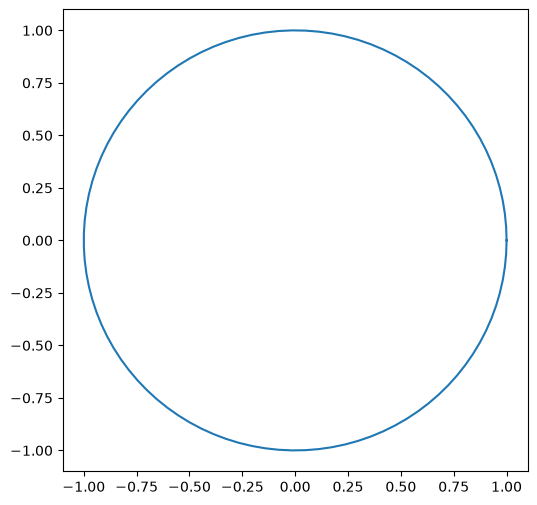

In [34]:
# this creates a figure with a size of 6x6
plt.figure(figsize=(6, 6))

# get the x and y coordinates of the circle
xs, ys = draw_circle(100, 1)

# plot the points
plt.plot(
    xs,
    ys
)

# show the plot
plt.show()

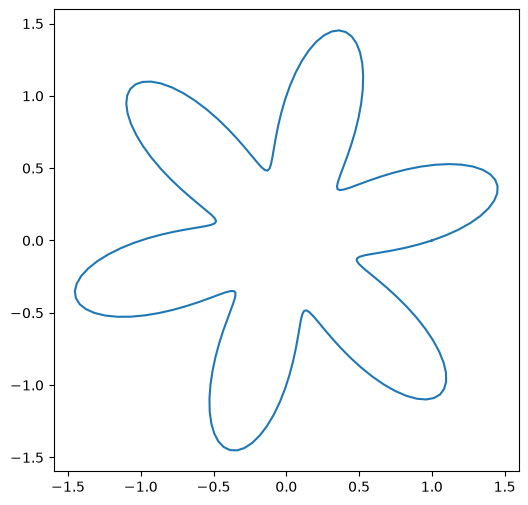

In [52]:
def draw_wave(resolution: int, radius: float, freq: float) -> tuple[list[float], list[float]]:
    xs = []
    ys = []

    for i in range(resolution):
        angle = 2 * m.pi * i / (resolution-1)

        r = radius + m.sin(freq * angle) * 0.5

        x = r * m.cos(angle)
        y = r * m.sin(angle)
        xs.append(x)
        ys.append(y)
    
    return xs, ys

plt.figure(figsize=(6, 6))

plt.plot(*draw_wave(200, 1, 6))

plt.show()

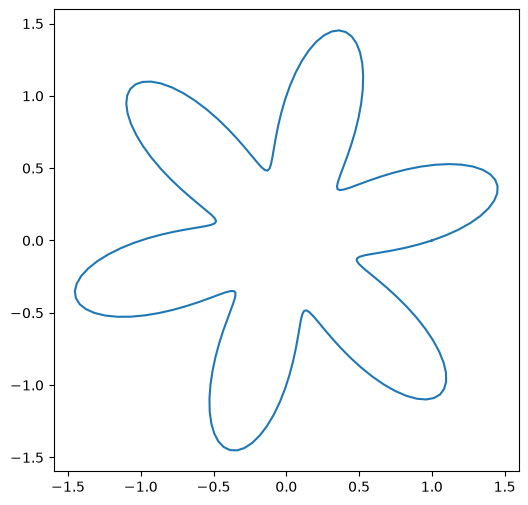

In [68]:
def draw_shifting_wave(resolution: int, radius: float, freq: float) -> tuple[list[float], list[float]]:
    xs = []
    ys = []

    if radius % 2 == 0:
        shift = m.pi
    else:
        shift = 0

    for i in range(resolution):
        angle = 2 * m.pi * i / (resolution-1)

        r = radius + m.sin(freq * angle + shift) * 0.5 

        x = r * m.cos(angle)
        y = r * m.sin(angle)
        xs.append(x)
        ys.append(y)
    
    return xs, ys

plt.figure(figsize=(6, 6))

plt.plot(*draw_wave(200, 1, 6))

plt.show()

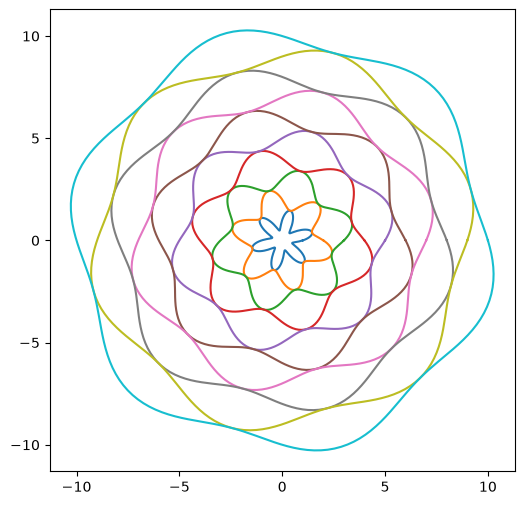

In [ ]:
loops = 10

fig, ax = plt.subplots(figsize=(6, 6))

for i in range(loops):
    xs, ys = draw_shifting_wave(200, i+1, 6)
    ax.plot(xs, ys)

plt.show()

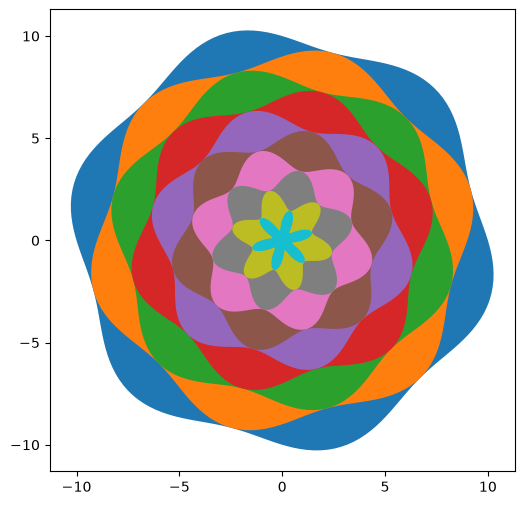

In [76]:
loops = 10

fig, ax = plt.subplots(figsize=(6, 6))

for i in range(loops):
    # xs, ys = draw_shifting_wave(200, i+1, 6)
    xs, ys = draw_shifting_wave(200, loops-i, 6)
    ax.fill(xs, ys)

plt.show()

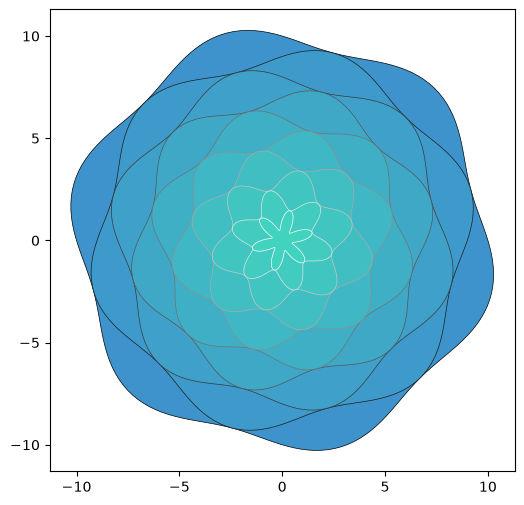

In [86]:
from PIL import ImageColor

def get_color_gradient(color_a, color_b, t):
    """
    color_a: tuple of RGB values for the first color as hex string
    color_b: tuple of RGB values for the second color as hex string
    t: float between 0 and 1 representing the interpolation factor
    Returns a tuple of RGB values representing the interpolated color.

    Source - https://stackoverflow.com/q/34839316
    Posted by Mini Mithi, modified by community. See post 'Timeline' for change history
    Retrieved 2026-09-23, License - CC BY-SA 4.0
    """
    def remap(old_val, old_min, old_max, new_min, new_max):
        return (new_max - new_min)*(old_val - old_min) / (old_max - old_min) + new_min

    # Convert hex color strings to RGB tuples
    color_a = ImageColor.getcolor(color_a, "RGB")
    color_b = ImageColor.getcolor(color_b, "RGB")

    return (
        remap(t, 0, 1, color_a[0], color_b[0])/255,
        remap(t, 0, 1, color_a[1], color_b[1])/255,
        remap(t, 0, 1, color_a[2], color_b[2])/255
    )

loops = 10

fig, ax = plt.subplots(figsize=(6, 6))

for i in range(loops):
    t = i / (loops - 1)  # Normalized value between 0 and 1
    xs, ys = draw_shifting_wave(200, loops-i, 6)
    ax.fill(
        xs, 
        ys,
        facecolor = get_color_gradient("#3E93CC", "#41D3BD", t),
        edgecolor = get_color_gradient("#000000", "#FFFFFF", t),
        linewidth = 0.5
    )

plt.show()